# Progetto Robot learning 
“Idea of yours to further improve the sim-to-real transfer in our simple scenario”


## Environment
### Pusher
#### Reward
he total reward is: ***reward*** *=* *reward_dist + reward_ctrl + reward_near*.

    - *reward_dist*:
    This reward is a measure of how far the object is from the target goal position,
    with a more negative value assigned if the object is further away from the target.
    It is $-w_{dist} \|(P_{object} - P_{target})\|_2$.
    where $w_{dist}$ is the `reward_dist_weight` (default is $1$).
    - *reward_ctrl*:
    A negative reward to penalize the pusher for taking actions that are too large.
    It is measured as the negative squared Euclidean norm of the action, i.e. as $-w_{control} \|action\|_2^2$.
    where $w_{control}$ is the `reward_control_weight` (default is $0.1$).
    - *reward_near*:
    This reward is a measure of how far the *fingertip* of the pusher (the unattached end) is from the object,
    with a more negative value assigned for when the pusher's *fingertip* is further away from the target.
    It is $-w_{near} \|(P_{fingertip} - P_{target})\|_2$.
    where $w_{near}$ is the `reward_near_weight` (default is $0.5$).

 

### hopper

 
## RL API
La differenza principale tra PPO (Proximal Policy Optimization) e SAC (Soft Actor-Critic) risiede nella loro natura on-policy/off-policy e nei meccanismi utilizzati per stabilizzare l'apprendimento:
Natura dell'algoritmo: PPO è un metodo on-policy, il che significa che richiede nuovi campioni di dati per ogni aggiornamento del gradiente, rendendolo meno efficiente nel campionamento. SAC è invece off-policy, permettendo il riutilizzo di esperienze passate tramite un replay buffer, il che lo rende molto più efficiente in termini di campioni necessari.
Obiettivo e Stabilità:
PPO ottimizza una funzione obiettivo "surrogata" e utilizza una tecnica di clipping dei rapporti di probabilità per evitare aggiornamenti troppo grandi e distruttivi della politica.
SAC si basa sul framework della massima entropia: l'agente cerca di massimizzare non solo la ricompensa attesa, ma anche l'entropia della politica (ovvero agire nel modo più casuale possibile pur avendo successo). Questo favorisce l'esplorazione e previene la convergenza prematura.
Prestazioni: SAC ha dimostrato di essere più stabile e performante in compiti di controllo continuo ad alta dimensione rispetto ad altri metodi off-policy, superando spesso anche PPO in termini di velocità di apprendimento e punteggio finale.
Quindi il sac dovrebbe essere migliore nel ambiente dell’hopper dove le masse del corpo variano casualmente, nel caso di un analisi a lungo termine perchè esplora di più così da ottenere massime reward anche in situazioni peggiori. Mentre il PPO impara più velocemente perchè segue una policy precisa senza andare ad esplorare ma basandosi solo sugli ambienti dove ha avuto risultai migliori








## Road Map
- Hopper environment
- Variazione delle masse delle masse
- Determinare quale massa è più rilevante
- Come influisce lo scostarsi dal valore di target 
- Confronto tra PPO e SAC
- test sim-to-real


## TEST HOPPER
Per il test sull'hopper siamo partiti creando 9 ideali ambienti di test variando del 5%, 25% e 55% dai valori nominali di 
- massa delle parti
- attrito tra il pamivento e i piede
- massa e attrito contemporaneamente

Abbiamo ottenuto i seguenti risultati:

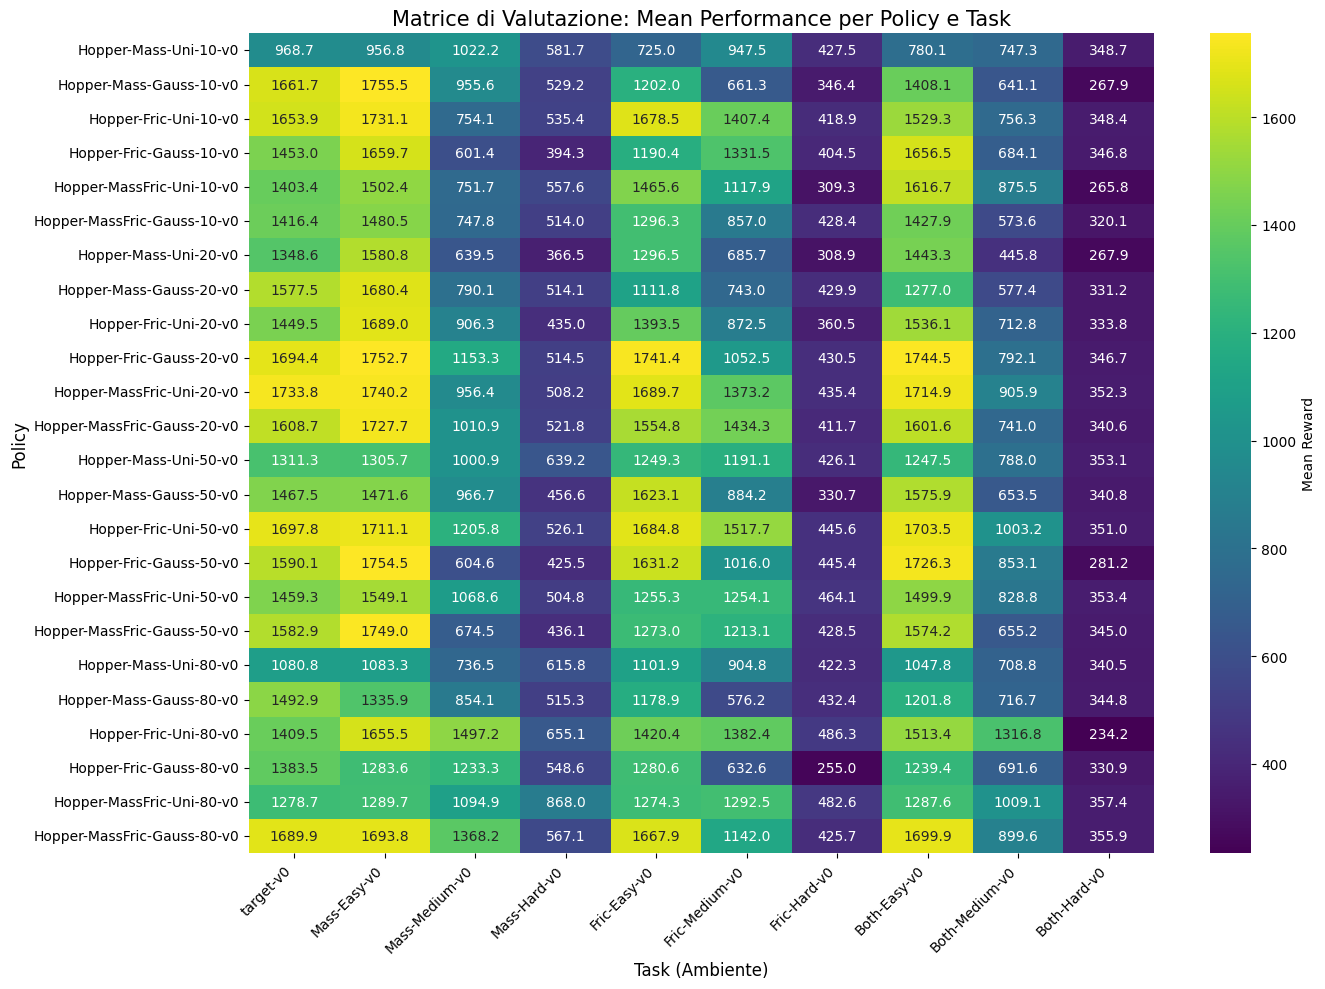

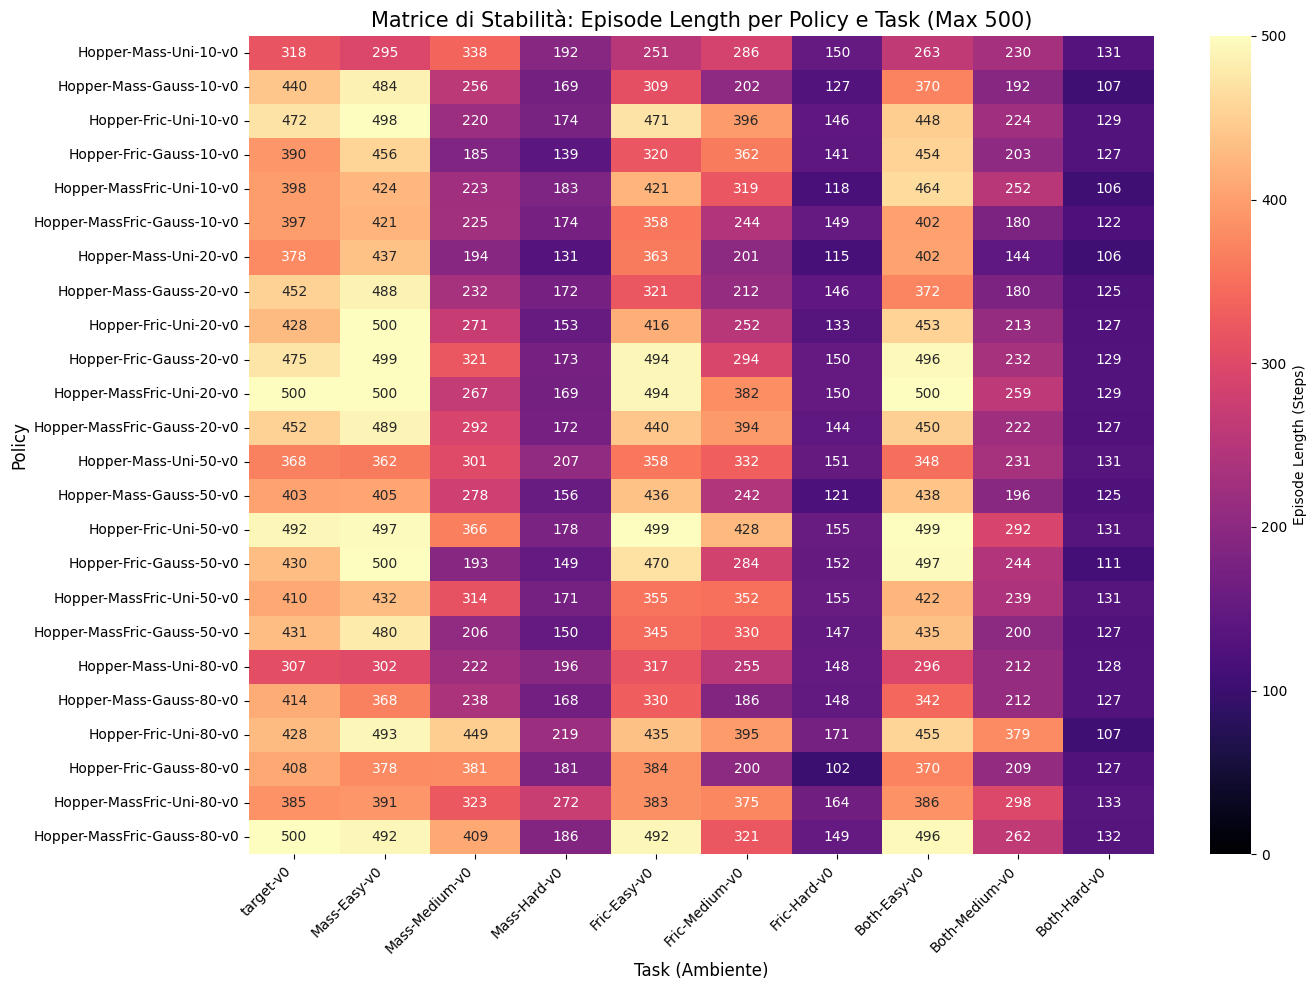

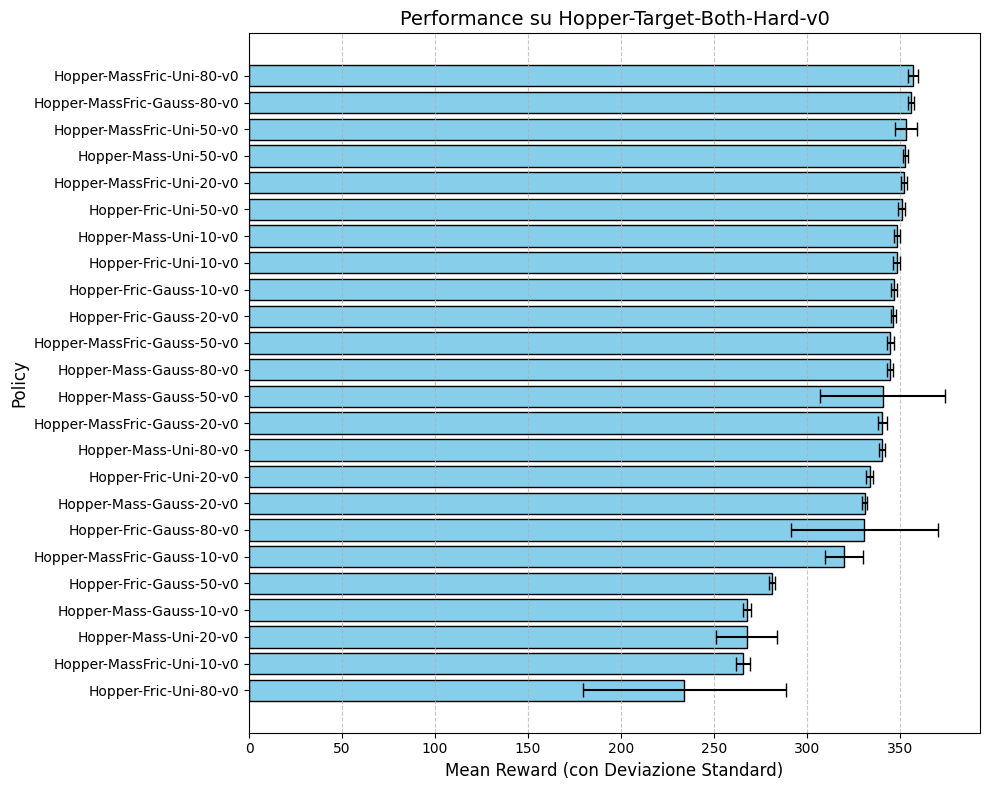

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Caricamento dei dati
# Assicurati di eseguire il notebook dalla cartella radice "Renforcement_Learning_Project"
df = pd.read_csv('HOPPER_ENV/PPO/results_v2/evaluation_matrix_v2.csv')

# Identifichiamo le colonne (uso endswith per essere più precisi)
mean_cols = [c for c in df.columns if c.endswith('_mean')]
std_cols = [c for c in df.columns if c.endswith('_std')]
len_cols = [c for c in df.columns if c.endswith('_ep_len')] # Nuova metrica di stabilità

# Pulizia nomi colonne per una visualizzazione migliore
clean_labels = [c.replace('_mean', '').replace('Hopper-Target-', '').replace('CustomHopper-', '') for c in mean_cols]

# --- VISUALIZZAZIONE 1: HEATMAP REWARD ---
plt.figure(figsize=(14, 10))
heatmap_data = df[mean_cols].copy()
heatmap_data.index = df['policy']
heatmap_data.columns = clean_labels

sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='viridis', cbar_kws={'label': 'Mean Reward'})
plt.title('Matrice di Valutazione: Mean Performance per Policy e Task', fontsize=15)
plt.xlabel('Task (Ambiente)', fontsize=12)
plt.ylabel('Policy', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('heatmap_results.png')
plt.show()

# --- VISUALIZZAZIONE 2: HEATMAP STABILITÀ (Episode Length) ---
plt.figure(figsize=(14, 10))
heatmap_len = df[len_cols].copy()
heatmap_len.index = df['policy']
# Usiamo le stesse etichette pulite
heatmap_len.columns = clean_labels

# Impostiamo vmin=0 e vmax=500 così i colori sono calibrati sulla lunghezza massima
sns.heatmap(heatmap_len, annot=True, fmt=".0f", cmap='magma', vmin=0, vmax=500, cbar_kws={'label': 'Episode Length (Steps)'})
plt.title('Matrice di Stabilità: Episode Length per Policy e Task (Max 500)', fontsize=15)
plt.xlabel('Task (Ambiente)', fontsize=12)
plt.ylabel('Policy', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('heatmap_stability.png')
plt.show()

# --- VISUALIZZAZIONE 3: BAR CHART (Esempio su un task specifico) ---
# Scegliamo un task impegnativo per il confronto, ad esempio "Both-Hard"
target_task_mean = 'Hopper-Target-Both-Hard-v0_mean'
target_task_std = 'Hopper-Target-Both-Hard-v0_std'

# Rimuoviamo eventuali righe con NaN per evitare errori in matplotlib e ordiniamo
df_sorted = df.dropna(subset=[target_task_mean, target_task_std]).sort_values(by=target_task_mean, ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(df_sorted['policy'], df_sorted[target_task_mean], 
         xerr=df_sorted[target_task_std], 
         color='skyblue', edgecolor='black', capsize=5)

plt.title(f'Performance su {target_task_mean.replace("_mean", "")}', fontsize=14)
plt.xlabel('Mean Reward (con Deviazione Standard)', fontsize=12)
plt.ylabel('Policy', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('performance_comparison.png')
plt.show()


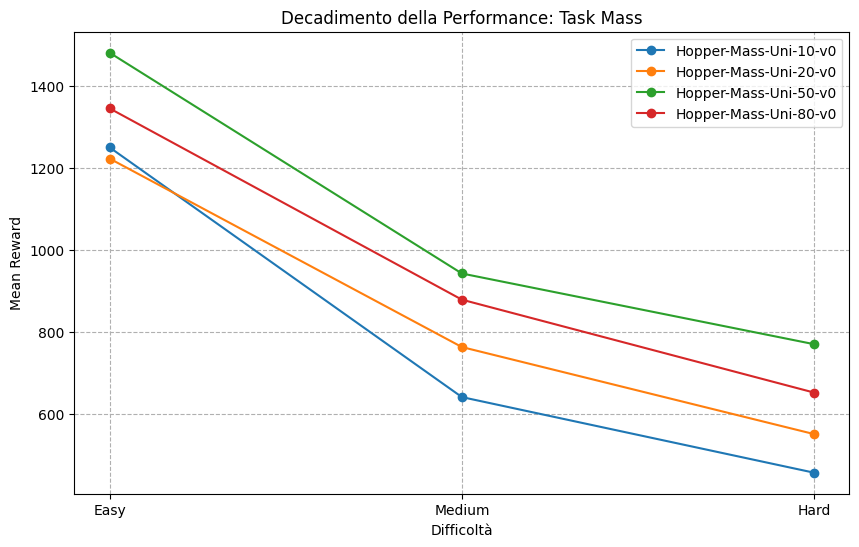

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('HOPPER_ENV/PPO/results/evaluation_matrix.csv')

# Selezioniamo un gruppo di policy da confrontare (es. quelle Mass-Uni)
policies_to_plot = [p for p in df['policy'] if 'Mass-Uni' in p]
difficulties = ['Easy', 'Medium', 'Hard']

plt.figure(figsize=(10, 6))

for policy in policies_to_plot:
    # Estraiamo i valori per Easy, Medium, Hard del task "Mass"
    values = [
        df.loc[df['policy'] == policy, f'Hopper-Target-Mass-{d}-v0_mean'].values[0]
        for d in difficulties
    ]
    plt.plot(difficulties, values, marker='o', label=policy)

plt.title('Decadimento della Performance: Task Mass')
plt.ylabel('Mean Reward')
plt.xlabel('Difficoltà')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

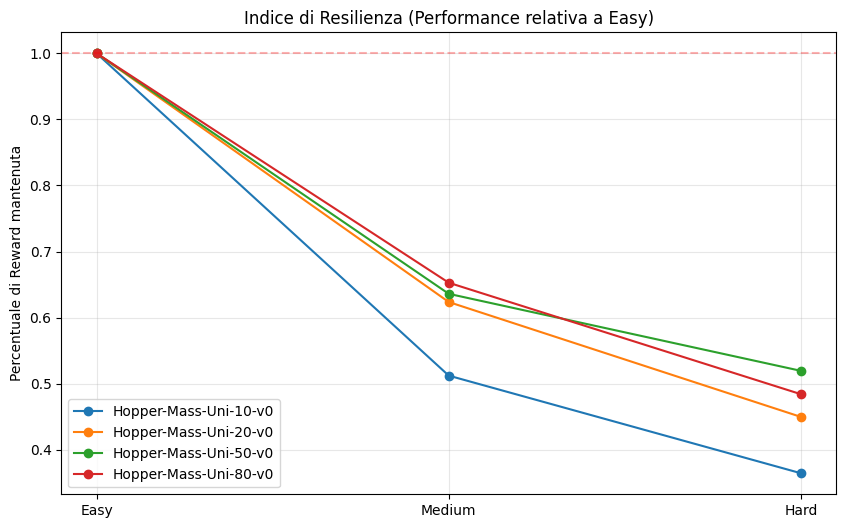

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('HOPPER_ENV/PPO/results/evaluation_matrix.csv')

# Filtriamo per un tipo di training, ad esempio 'Mass-Uni'
subset = df[df['policy'].str.contains('Mass-Uni')]
diffs = ['Easy', 'Medium', 'Hard']

plt.figure(figsize=(10, 6))

for _, row in subset.iterrows():
    # Calcoliamo la performance relativa: (Valore / Valore_Easy)
    base_val = row['Hopper-Target-Mass-Easy-v0_mean']
    relative_values = [
        row[f'Hopper-Target-Mass-{d}-v0_mean'] / base_val for d in diffs
    ]
    plt.plot(diffs, relative_values, marker='o', label=row['policy'])

plt.axhline(1, color='red', linestyle='--', alpha=0.3)
plt.title('Indice di Resilienza (Performance relativa a Easy)')
plt.ylabel('Percentuale di Reward mantenuta')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
import gymnasium as gym
from stable_baselines3 import PPO

# Importa il modulo contenente i tuoi ambienti custom per registrarli in Gymnasium
# (Assicurati che il percorso di importazione sia corretto rispetto a dove si trova il notebook)
import HOPPER_ENV.PPO.env.custom_hopper

# Crea l'ambiente custom con il rendering attivo
# Dal nome del modello "uni_80", presumo tu voglia testare la variante Uniforme all'80%
env = gym.make("Hopper-Mass-Uni-80-v0", render_mode="human")

# Carica il tuo modello (inserisci il percorso corretto al file .zip)
model_path = "HOPPER_ENV/PPO/results/models/Fric-Uni/80/PPO_Hopper-Fric-Uni-80-v0_s90161.zip"
model = PPO.load(model_path)

obs, info = env.reset()
for _ in range(1000):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    
    # env.render() non è più necessario qui dentro; 
    # render_mode="human" fa sì che venga renderizzato automaticamente in step()
    
    if terminated or truncated:
        obs, info = env.reset()

# È buona norma chiudere l'ambiente al termine della simulazione
env.close()


c:\Users\leona\Programmi\Anaconda\Programma\envs\robotlearning\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


### Analisi Ottimizzazione
Tramite l'algoritmo di Optuna abbiamo provato a massimizzare la reward media in un milione di timesteps per il modello con la maggior randomizzazione.

Migliori Parametri:
  learning_rate: 9.682609487894454e-05
  n_steps: 1024
  batch_size: 64
  n_epochs: 15
  gamma: 0.9948646413801842
  gae_lambda: 0.956474414048344
  clip_range: 0.17298348295317015
  ent_coef: 0.0002674701807186936
  vf_coef: 0.7848396206682986
  max_grad_norm: 0.7245950693318323


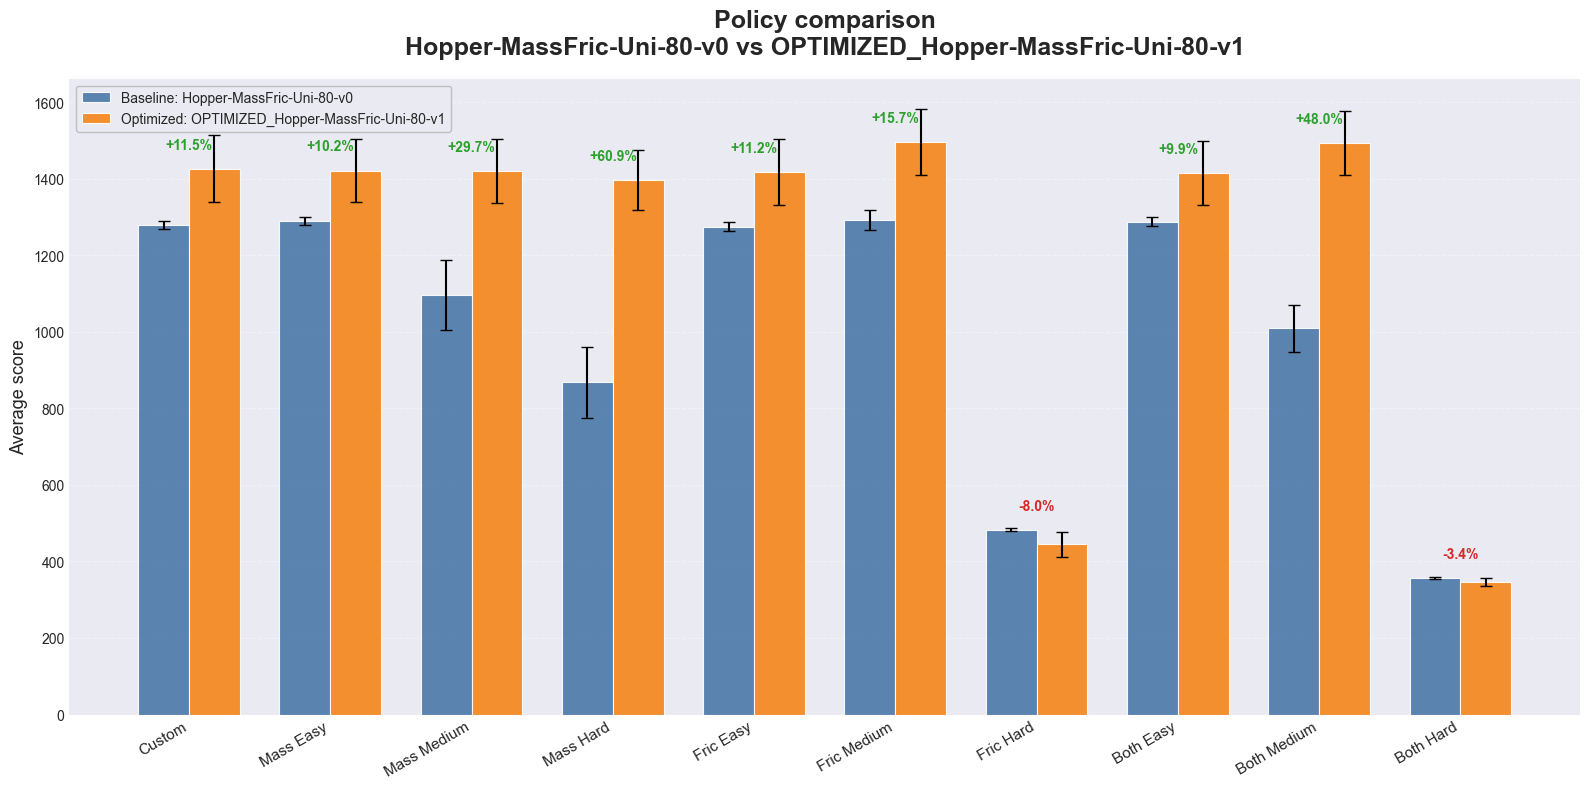

,metric,baseline,optimized,delta_pct
0,Custom,1278.69 ± 9.45,1425.9 ± 87.04,11.51
1,Mass Easy,1289.65 ± 10.45,1421.04 ± 81.59,10.19
2,Mass Medium,1094.88 ± 91.29,1419.81 ± 83.56,29.68
3,Mass Hard,867.99 ± 93.48,1396.31 ± 77.81,60.87
4,Fric Easy,1274.27 ± 11.28,1417.4 ± 87.09,11.23
5,Fric Medium,1292.5 ± 26.69,1496.03 ± 86.25,15.75
6,Fric Hard,482.58 ± 4.04,444.21 ± 31.77,-7.95
7,Both Easy,1287.61 ± 11.4,1414.67 ± 83.54,9.87
8,Both Medium,1009.15 ± 61.12,1493.44 ± 84.18,47.99
9,Both Hard,357.36 ± 2.76,345.32 ± 10.48,-3.37


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# CONFIG
# =========================
base_file = "HOPPER_ENV/PPO/results_v2/evaluation_matrix_v2.csv"
opt_file = "HOPPER_ENV/PPO/results_v2/evaluation_matrix_OPTIMIZED.csv"

baseline_policy = "Hopper-MassFric-Uni-80-v0"  # <-- La policy di default corrispondente

# =========================
# LOAD DATA
# =========================
df_base = pd.read_csv(base_file)
df_opt = pd.read_csv(opt_file)

if baseline_policy not in df_base["policy"].values:
    raise ValueError(
        f"Policy '{baseline_policy}' non trovata!\n"
        f"Disponibili: {list(df_base['policy'])}"
    )

base_row = df_base[df_base["policy"] == baseline_policy].iloc[0]
opt_row = df_opt.iloc[0]
opt_policy_name = opt_row["policy"]

mean_cols = [c for c in df_base.columns if c.endswith("_mean")]

# =========================
# LABELS PIÙ LEGGIBILI
# =========================
label_map = {
    "CustomHopper-target-v0_mean": "Custom",
    "Hopper-Target-Mass-Easy-v0_mean": "Mass Easy",
    "Hopper-Target-Mass-Medium-v0_mean": "Mass Medium",
    "Hopper-Target-Mass-Hard-v0_mean": "Mass Hard",
    "Hopper-Target-Fric-Easy-v0_mean": "Fric Easy",
    "Hopper-Target-Fric-Medium-v0_mean": "Fric Medium",
    "Hopper-Target-Fric-Hard-v0_mean": "Fric Hard",
    "Hopper-Target-Both-Easy-v0_mean": "Both Easy",
    "Hopper-Target-Both-Medium-v0_mean": "Both Medium",
    "Hopper-Target-Both-Hard-v0_mean": "Both Hard",
}

results = []

for mean_col in mean_cols:
    std_col = mean_col.replace("_mean", "_std")
    
    baseline_mean = float(base_row[mean_col])
    baseline_std = float(base_row[std_col])
    optimized_mean = float(opt_row[mean_col])
    optimized_std = float(opt_row[std_col])
    
    delta_pct = 100 * (optimized_mean - baseline_mean) / baseline_mean if baseline_mean != 0 else np.nan

    results.append({
        "metric": label_map.get(mean_col, mean_col.replace("_mean", "")),
        "baseline_mean": baseline_mean,
        "baseline_std": baseline_std,
        "optimized_mean": optimized_mean,
        "optimized_std": optimized_std,
        "delta_pct": delta_pct
    })

df_plot = pd.DataFrame(results)

# =========================
# STILE PLOT
# =========================
plt.style.use("seaborn-v0_8-darkgrid")

baseline_color = "#4C78A8"
optimized_color = "#F58518"
text_color = "#EAEAF2"

x = np.arange(len(df_plot))
width = 0.36

fig, ax = plt.subplots(figsize=(16, 8))

bars1 = ax.bar(
    x - width/2,
    df_plot["baseline_mean"],
    width,
    yerr=df_plot["baseline_std"],
    capsize=4,
    label=f"Baseline: {baseline_policy}",
    color=baseline_color,
    alpha=0.90,
    edgecolor="white",
    linewidth=0.8
)

bars2 = ax.bar(
    x + width/2,
    df_plot["optimized_mean"],
    width,
    yerr=df_plot["optimized_std"],
    capsize=4,
    label=f"Optimized: {opt_policy_name}",
    color=optimized_color,
    alpha=0.90,
    edgecolor="white",
    linewidth=0.8
)

# Titolo e assi
ax.set_title(
    f"Policy comparison\n{baseline_policy} vs {opt_policy_name}",
    fontsize=18,
    fontweight="bold",
    pad=18
)
ax.set_ylabel("Average score", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(df_plot["metric"], rotation=30, ha="right", fontsize=11)

# Griglia più pulita
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", visible=False)

# Legenda
leg = ax.legend(frameon=True, fancybox=True, framealpha=0.9)
leg.get_frame().set_edgecolor("#BBBBBB")

# Annotazioni delta %
for i, delta in enumerate(df_plot["delta_pct"]):
    ymax = max(df_plot.loc[i, "baseline_mean"], df_plot.loc[i, "optimized_mean"])
    ytext = ymax + max(df_plot["optimized_mean"].max(), df_plot["baseline_mean"].max()) * 0.03
    
    color = "#2ca02c" if delta >= 0 else "#d62728"
    ax.text(
        i,
        ytext,
        f"{delta:+.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=color
    )

# Rimuove spine superflue
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# =========================
# TABELLA RISULTATI PER JUPYTER
# =========================
df_table = df_plot.copy()
df_table["baseline"] = df_table["baseline_mean"].round(2).astype(str) + " ± " + df_table["baseline_std"].round(2).astype(str)
df_table["optimized"] = df_table["optimized_mean"].round(2).astype(str) + " ± " + df_table["optimized_std"].round(2).astype(str)
df_table["delta_pct"] = df_table["delta_pct"].round(2)

df_table = df_table[["metric", "baseline", "optimized", "delta_pct"]]
df_table


### SAC


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Definizione dei percorsi
BASE_DIR = r"C:\Users\leona\Documents\Politecnico\Robot Learning\Esercitazione\Progetto\Renforcement_Learning_Project\HOPPER_ENV"
ppo_csv_path = os.path.join(BASE_DIR, "PPO", "results_v2", "evaluation_matrix_v2.csv")
sac_csv_path = os.path.join(BASE_DIR, "SAC", "results", "evaluation_matrix_SAC.csv")

# 2. Caricamento dei dati
df_ppo = pd.read_csv(ppo_csv_path)
df_sac = pd.read_csv(sac_csv_path)

print("Policy disponibili nel PPO:", df_ppo['policy'].unique())
print("Policy disponibili nel SAC:", df_sac['policy'].unique())
print("-" * 50)

# 3. Filtraggio intelligente: cerca qualsiasi policy che contenga 'source' nel nome
ppo_source_df = df_ppo[df_ppo['policy'].str.contains('source', case=False, na=False)]
sac_source_df = df_sac[df_sac['policy'].str.contains('source', case=False, na=False)]

if ppo_source_df.empty:
    raise ValueError("ERRORE: Nessuna policy contenente la parola 'source' trovata nel CSV del PPO. Rilancia evaluate_policy_v1.py!")
if sac_source_df.empty:
    raise ValueError("ERRORE: Nessuna policy contenente la parola 'source' trovata nel CSV del SAC.")

ppo_source = ppo_source_df.iloc[0]
sac_source = sac_source_df.iloc[0]

# Lista dei target da valutare
target_ids = [
    "CustomHopper-target-v0", "Hopper-Target-Mass-Easy-v0", "Hopper-Target-Mass-Medium-v0",
    "Hopper-Target-Mass-Hard-v0", "Hopper-Target-Fric-Easy-v0", "Hopper-Target-Fric-Medium-v0",
    "Hopper-Target-Fric-Hard-v0", "Hopper-Target-Both-Easy-v0", "Hopper-Target-Both-Medium-v0",
    "Hopper-Target-Both-Hard-v0",
]

# 4. Estrazione Dati
ppo_means = [ppo_source[f"{t}_mean"] for t in target_ids]
ppo_stds  = [ppo_source[f"{t}_std"] for t in target_ids]

sac_means = [sac_source[f"{t}_mean"] for t in target_ids]
sac_stds  = [sac_source[f"{t}_std"] for t in target_ids]

labels = [t.replace("Hopper-Target-", "").replace("CustomHopper-", "").replace("-v0", "") for t in target_ids]

# 5. Creazione Grafico
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(x - width/2, ppo_means, width, yerr=ppo_stds, label='PPO (Source)', capsize=5, color='#4C72B0', edgecolor='black', alpha=0.9)
ax.bar(x + width/2, sac_means, width, yerr=sac_stds, label='SAC (Source)', capsize=5, color='#DD8452', edgecolor='black', alpha=0.9)

ax.set_ylabel('Mean Reward', fontsize=12, fontweight='bold')
ax.set_title('Confronto Zero-Shot Performance: PPO vs SAC', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Linee base
ax.axhline(y=ppo_means[0], color='#4C72B0', linestyle=':', alpha=0.6)
ax.axhline(y=sac_means[0], color='#DD8452', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


Policy disponibili nel PPO: ['Hopper-Mass-Uni-10-v0' 'Hopper-Mass-Gauss-10-v0' 'Hopper-Fric-Uni-10-v0'
 'Hopper-Fric-Gauss-10-v0' 'Hopper-MassFric-Uni-10-v0'
 'Hopper-MassFric-Gauss-10-v0' 'Hopper-Mass-Uni-20-v0'
 'Hopper-Mass-Gauss-20-v0' 'Hopper-Fric-Uni-20-v0'
 'Hopper-Fric-Gauss-20-v0' 'Hopper-MassFric-Uni-20-v0'
 'Hopper-MassFric-Gauss-20-v0' 'Hopper-Mass-Uni-50-v0'
 'Hopper-Mass-Gauss-50-v0' 'Hopper-Fric-Uni-50-v0'
 'Hopper-Fric-Gauss-50-v0' 'Hopper-MassFric-Uni-50-v0'
 'Hopper-MassFric-Gauss-50-v0' 'Hopper-Mass-Uni-80-v0'
 'Hopper-Mass-Gauss-80-v0' 'Hopper-Fric-Uni-80-v0'
 'Hopper-Fric-Gauss-80-v0' 'Hopper-MassFric-Uni-80-v0'
 'Hopper-MassFric-Gauss-80-v0']
Policy disponibili nel SAC: ['CustomHopper-source-v0']
--------------------------------------------------


ValueError: ERRORE: Nessuna policy contenente la parola 'source' trovata nel CSV del PPO. Rilancia evaluate_policy_v1.py!

## Test Pusher


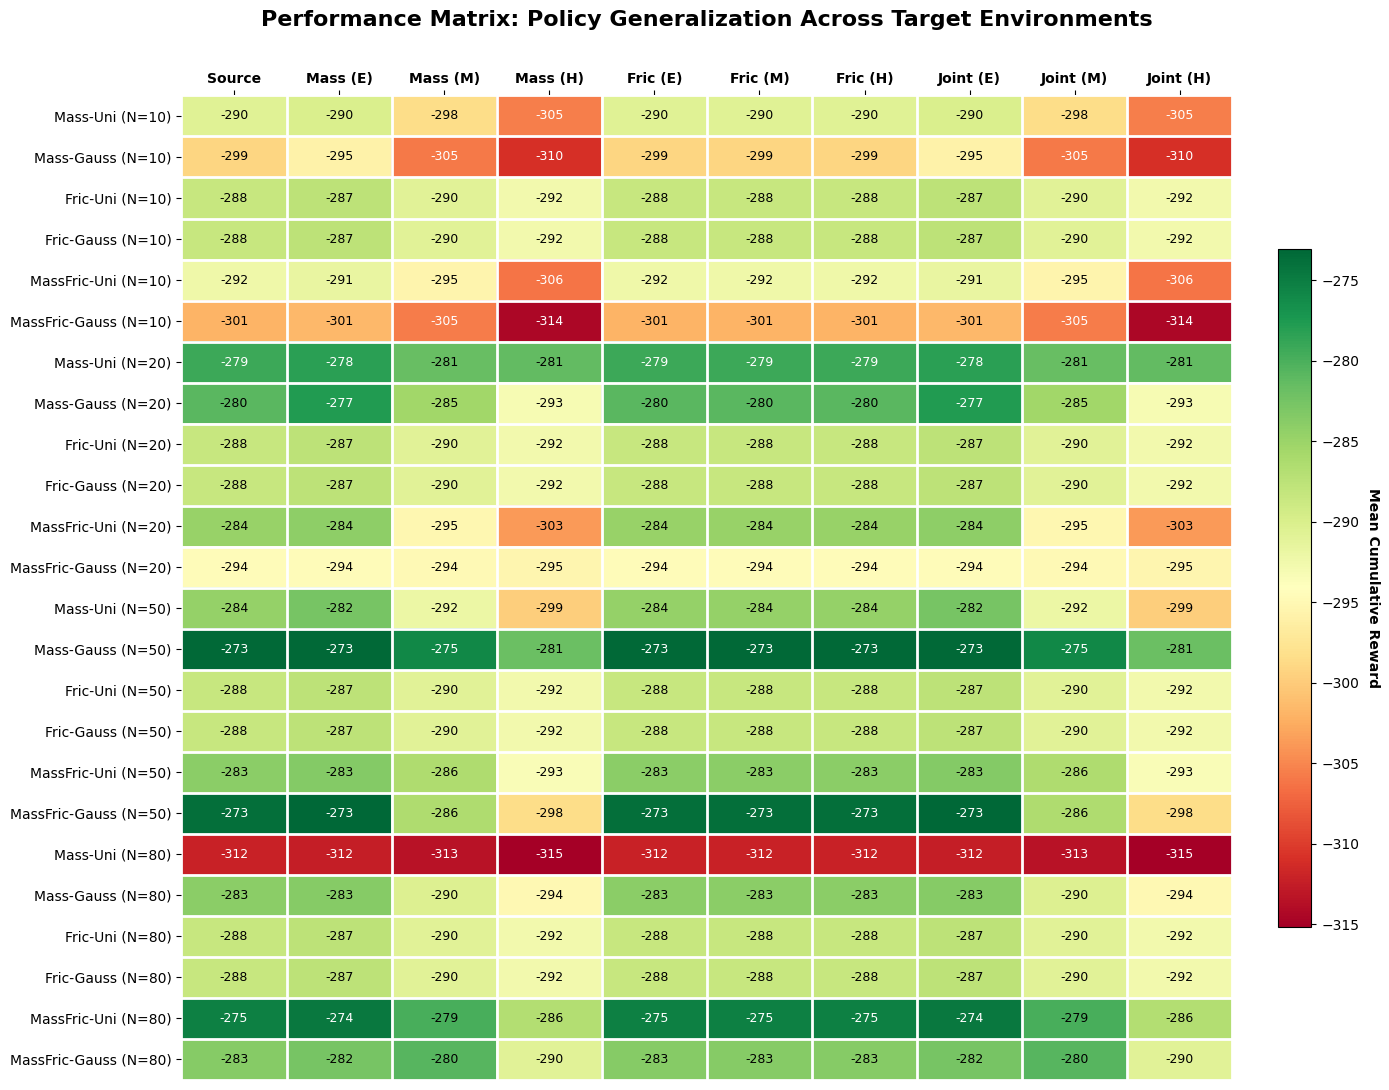

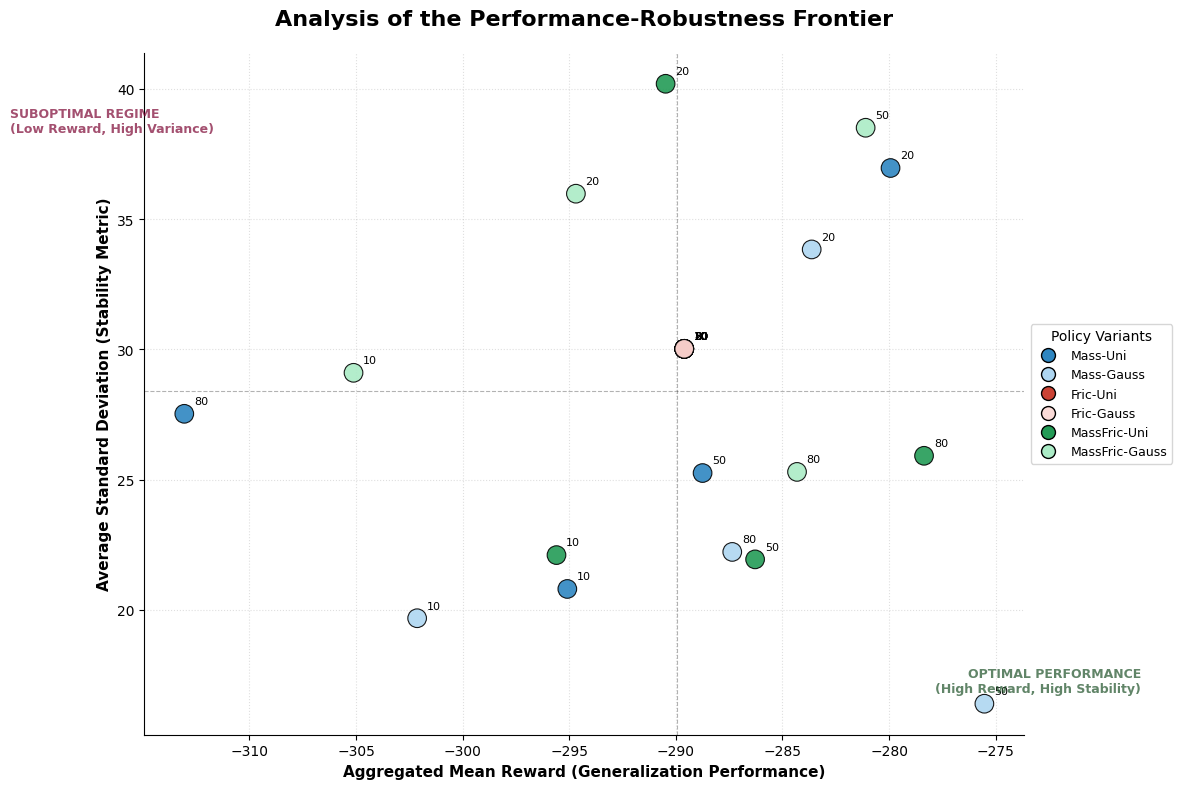

Grafici salvati con successo: 'pusher_heatmap_academic.png' e 'pusher_scatter_academic.png'


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.lines import Line2D

# ═══════════════════════════════════════════════════════════════
# 1. DATA PREPROCESSING (ALLINEATO AL FILE PUSHER)
# ═══════════════════════════════════════════════════════════════
def load_and_prepare_pusher_data(file_path):
    df = pd.read_csv(file_path)
    
    # Lista dei target allineata alle colonne del CSV Pusher
    targets = [
        "CustomPusher-target-v0",
        "Pusher-Target-Mass-Easy-v0", "Pusher-Target-Mass-Medium-v0", "Pusher-Target-Mass-Hard-v0",
        "Pusher-Target-Fric-Easy-v0", "Pusher-Target-Fric-Medium-v0", "Pusher-Target-Fric-Hard-v0",
        "Pusher-Target-Both-Easy-v0", "Pusher-Target-Both-Medium-v0", "Pusher-Target-Both-Hard-v0",
    ]
    
    # Etichette Accademiche per i Target
    target_labels = [
        "Source", "Mass (E)", "Mass (M)", "Mass (H)",
        "Fric (E)", "Fric (M)", "Fric (H)",
        "Joint (E)", "Joint (M)", "Joint (H)"
    ]
    
    policy_info = []
    for p in df["policy"]:
        parts = p.split('-')
        # Estrazione esatta della base (es. MassFric-Uni) e dei campioni (N)
        base = f"{parts[1]}-{parts[2]}"
        seeds = parts[3]
        policy_info.append({
            "full_label": f"{base} (N={seeds})",
            "base": base,
            "seeds": seeds
        })
    
    # Estrazione matrici (pattern: _mean e _std_seed)
    matrix_mean = np.array([df[f"{t}_mean"].values for t in targets]).T
    matrix_std = np.array([df[f"{t}_std_seed"].values for t in targets]).T
    
    # Metriche aggregate per l'analisi della frontiera
    row_means = matrix_mean.mean(axis=1)
    row_stds = matrix_std.mean(axis=1)
    
    return matrix_mean, policy_info, target_labels, row_means, row_stds

# ═══════════════════════════════════════════════════════════════
# 2. FIGURE 1: CROSS-ENVIRONMENT PERFORMANCE MATRIX
# ═══════════════════════════════════════════════════════════════
def draw_heatmap(matrix, p_info, t_labels):
    fig, ax = plt.subplots(figsize=(14, 11), facecolor='white')
    
    p_labels = [info["full_label"] for info in p_info]
    vmin, vmax = matrix.min(), matrix.max()
    
    im = ax.imshow(matrix, aspect="auto", cmap="RdYlGn", 
                   norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
    
    # Annotazione valori con contrasto dinamico
    for i in range(len(p_labels)):
        for j in range(len(t_labels)):
            val = matrix[i, j]
            norm_val = (val - vmin) / (vmax - vmin)
            color = "white" if norm_val < 0.25 or norm_val > 0.85 else "black"
            ax.text(j, i, f"{int(val)}", ha="center", va="center", 
                    fontsize=9, color=color, fontweight='medium')

    # Configurazione assi e label
    ax.set_xticks(np.arange(len(t_labels)))
    ax.set_yticks(np.arange(len(p_labels)))
    ax.set_xticklabels(t_labels, fontsize=10, fontweight='bold')
    ax.set_yticklabels(p_labels, fontsize=10)
    ax.xaxis.set_ticks_position('top')
    
    # Griglia di delimitazione celle
    ax.set_xticks(np.arange(len(t_labels)+1)-.5, minor=True)
    ax.set_yticks(np.arange(len(p_labels)+1)-.5, minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=2)
    ax.tick_params(which="minor", size=0)
    
    for s in ax.spines.values(): s.set_visible(False)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label("Mean Cumulative Reward", rotation=270, labelpad=15, fontweight='bold')

    plt.title("Performance Matrix: Policy Generalization Across Target Environments", 
              fontsize=16, fontweight='bold', pad=50)
    plt.tight_layout()
    plt.savefig("pusher_heatmap_academic.png", dpi=300)
    plt.show()

# ═══════════════════════════════════════════════════════════════
# 3. FIGURE 2: PERFORMANCE-ROBUSTNESS PARETO ANALYSIS
# ═══════════════════════════════════════════════════════════════
def draw_scatter(means, stds, p_info):
    fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')
    
    # Mappatura cromatica categoriale (distingue Mass da MassFric)
    color_map = {
        "Mass-Uni": "#2E86C1",       
        "Mass-Gauss": "#AED6F1",     
        "Fric-Uni": "#CB4335",       
        "Fric-Gauss": "#FADBD8",     
        "MassFric-Uni": "#239B56",    
        "MassFric-Gauss": "#ABEBC6"   
    }
    
    point_colors = [color_map.get(info["base"], "gray") for info in p_info]
    
    # Scatter plot dei dati
    ax.scatter(means, stds, c=point_colors, s=180, edgecolors='black', 
               linewidth=0.8, alpha=0.9, zorder=5)
    
    # Linee di base (medie globali)
    ax.axvline(np.mean(means), color='black', linestyle='--', linewidth=0.8, alpha=0.3)
    ax.axhline(np.mean(stds), color='black', linestyle='--', linewidth=0.8, alpha=0.3)
    
    # Annotazione del numero di seeds (N) vicino ai punti
    for i, info in enumerate(p_info):
        ax.annotate(info["seeds"], (means[i], stds[i]), xytext=(7, 7), 
                    textcoords='offset points', fontsize=8)

    # Definizioni accademiche dei quadranti
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.text(xlim[1]*0.98, ylim[0]*1.1, "OPTIMAL PERFORMANCE\n(High Reward, High Stability)", 
            ha='right', va='bottom', color='#1E5128', fontsize=9, fontweight='bold', alpha=0.7)
    ax.text(xlim[0]*1.02, ylim[1]*0.95, "SUBOPTIMAL REGIME\n(Low Reward, High Variance)", 
            ha='left', va='top', color='#7D0633', fontsize=9, fontweight='bold', alpha=0.7)

    ax.set_xlabel("Aggregated Mean Reward (Generalization Performance)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Average Standard Deviation (Stability Metric)", fontsize=11, fontweight='bold')
    
    # Legenda categoriale
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=k, 
                              markerfacecolor=v, markersize=10, markeredgecolor='black') 
                       for k, v in color_map.items()]
    ax.legend(handles=legend_elements, title="Policy Variants", 
              loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=9)
    
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.title("Analysis of the Performance-Robustness Frontier", fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig("pusher_scatter_academic.png", dpi=300)
    plt.show()

# ═══════════════════════════════════════════════════════════════
# EXECUTION
# ═══════════════════════════════════════════════════════════════
if __name__ == "__main__":
    # Caricamento del file CSV caricato
    path = 'PUSHER_ENV/PPO/results_pusher/evaluation_matrix.csv'
    
    try:
        m_mean, p_info, t_labels, r_means, r_stds = load_and_prepare_pusher_data(path)
        
        # Generazione dei plot
        draw_heatmap(m_mean, p_info, t_labels)
        draw_scatter(r_means, r_stds, p_info)
        
        print("Grafici salvati con successo: 'pusher_heatmap_academic.png' e 'pusher_scatter_academic.png'")
        
    except Exception as e:
        print(f"Errore durante l'elaborazione: {e}")